In [1]:
!pip install rasterio geopandas ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00


In [2]:
import os, random, shutil, rasterio, torch, cv2, time

import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import colors, patches
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from rasterio.windows import Window
from rasterio.features import shapes
from rasterio.transform import Affine
from shapely.geometry import Polygon, Point, MultiPolygon, box, shape

from ultralytics import YOLO
from IPython.display import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
new_model = YOLO('/content/drive/MyDrive/AGRI/Detection/best.pt')

In [20]:
start_cpu_time = time.process_time()

def detect_single_resolution(image_path, model, output_dir, tile_size=640, overlap=16,
                             resolution=0.30, conf_threshold=0.3):
    """
    Optimized single-resolution detection with efficient processing
    """
    all_points = []
    detection_points_pixel = []
    detection_boxes = []
    counts_per_tile = []

    with rasterio.open(image_path) as src:
        original_width, original_height = src.width, src.height
        transform = src.transform
        crs = src.crs

        print(f"Original image size: {original_width}x{original_height}")

        # Calculate new dimensions
        new_width = int(original_width * resolution)
        new_height = int(original_height * resolution)
        print(f"Scaled image size: {new_width}x{new_height}")

        # Read and resize the full image once
        full_image = src.read([1, 2, 3])
        full_image = np.transpose(full_image, (1, 2, 0))
        full_image = np.clip(full_image, 0, 255).astype(np.uint8)
        resized_image = cv2.resize(full_image, (new_width, new_height), interpolation=cv2.INTER_LINEAR)

        # Pre-allocate lists for better memory efficiency
        tile_positions = []
        for y in range(0, new_height, tile_size - overlap):
            for x in range(0, new_width, tile_size - overlap):
                x_end = min(x + tile_size, new_width)
                y_end = min(y + tile_size, new_height)
                tile_positions.append((x, y, x_end, y_end))

        print(f"Processing {len(tile_positions)} tiles...")
        tile_id = 0

        # Process tiles
        for x, y, x_end, y_end in tqdm(tile_positions, desc="Detecting trees"):
            win_w = x_end - x
            win_h = y_end - y

            # Extract and prepare tile
            tile = resized_image[y:y_end, x:x_end]

            if tile.shape[:2] != (tile_size, tile_size):
                tile = cv2.resize(tile, (tile_size, tile_size))
                scale_x = win_w / tile_size
                scale_y = win_h / tile_size
            else:
                scale_x = scale_y = 1.0

            tile = np.ascontiguousarray(tile)

            # Run detection
            results = model.predict(source=tile, conf=conf_threshold,
                                   save_txt=False, save_conf=True, verbose=False)

            detection_count = 0

            if results[0].boxes is not None and len(results[0].boxes) > 0:
                boxes = results[0].boxes.xyxy.cpu().numpy()
                confidences = results[0].boxes.conf.cpu().numpy()
                detection_count = len(boxes)

                # Vectorized coordinate transformation
                bx_scaled = boxes * np.array([scale_x, scale_y, scale_x, scale_y])
                centers_x = (bx_scaled[:, 0] + bx_scaled[:, 2]) / 2
                centers_y = (bx_scaled[:, 1] + bx_scaled[:, 3]) / 2

                global_x = x + centers_x
                global_y = y + centers_y

                original_x = global_x / resolution
                original_y = global_y / resolution

                # Process each detection
                for i in range(len(boxes)):
                    px, py = rasterio.transform.xy(transform, original_y[i], original_x[i])

                    detection_points_pixel.append({
                        'x': original_x[i],
                        'y': original_y[i],
                        'confidence': confidences[i],
                        'tile_id': tile_id
                    })

                    all_points.append(Point(px, py))

                    detection_boxes.append({
                        'x1': original_x[i] - (bx_scaled[i, 2] - bx_scaled[i, 0])/(2*resolution),
                        'y1': original_y[i] - (bx_scaled[i, 3] - bx_scaled[i, 1])/(2*resolution),
                        'x2': original_x[i] + (bx_scaled[i, 2] - bx_scaled[i, 0])/(2*resolution),
                        'y2': original_y[i] + (bx_scaled[i, 3] - bx_scaled[i, 1])/(2*resolution),
                        'confidence': confidences[i],
                        'tile_id': tile_id
                    })

            counts_per_tile.append({
                "tile_id": tile_id,
                "count": detection_count,
                "x": x, "y": y,
                "width": win_w, "height": win_h
            })

            tile_id += 1

    print(f"\nTotal detections: {len(detection_points_pixel)}")
    return all_points, detection_points_pixel, detection_boxes, counts_per_tile

In [21]:
def visualize_detections(image_path, detection_points_pixel, output_dir, bands=[1,2,3]):
    """
    Create visualization of detections
    """
    fig, ax = plt.subplots(figsize=(15, 15))
    ax.set_title("Tree Detections", fontsize=16)
    ax.set_axis_off()

    with rasterio.open(image_path) as src:
        width, height = src.width, src.height
        background_img = src.read(bands)
        background_img = np.transpose(background_img, (1, 2, 0))
        background_img = np.clip(background_img / 255.0, 0, 1)

    ax.imshow(background_img, extent=[0, width, height, 0], alpha=0.7)

    if detection_points_pixel:
        x_coords = [d['x'] for d in detection_points_pixel]
        y_coords = [d['y'] for d in detection_points_pixel]
        confidences = [d['confidence'] for d in detection_points_pixel]

        scatter = ax.scatter(x_coords, y_coords, c=confidences, cmap='plasma',
                           s=50, alpha=0.8, edgecolors='white', linewidths=1,
                           vmin=0, vmax=1)

        plt.colorbar(scatter, ax=ax, label='Confidence', shrink=0.8)

        avg_conf = np.mean(confidences)
        stats_text = f"Total: {len(detection_points_pixel)}\nAvg Conf: {avg_conf:.3f}"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=12,
               verticalalignment='top', bbox=dict(boxstyle="round", fc="white", alpha=0.9))

    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)

    plt.savefig(f'{output_dir}/tree_detections.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

Starting tree detection at 0.3x resolution...
Original image size: 6000x4000
Scaled image size: 1800x1200


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Processing 2 tiles...


Detecting trees: 100%|██████████| 2/2 [00:06<00:00,  3.14s/it]



Total detections: 82

Detection complete! Creating visualization...


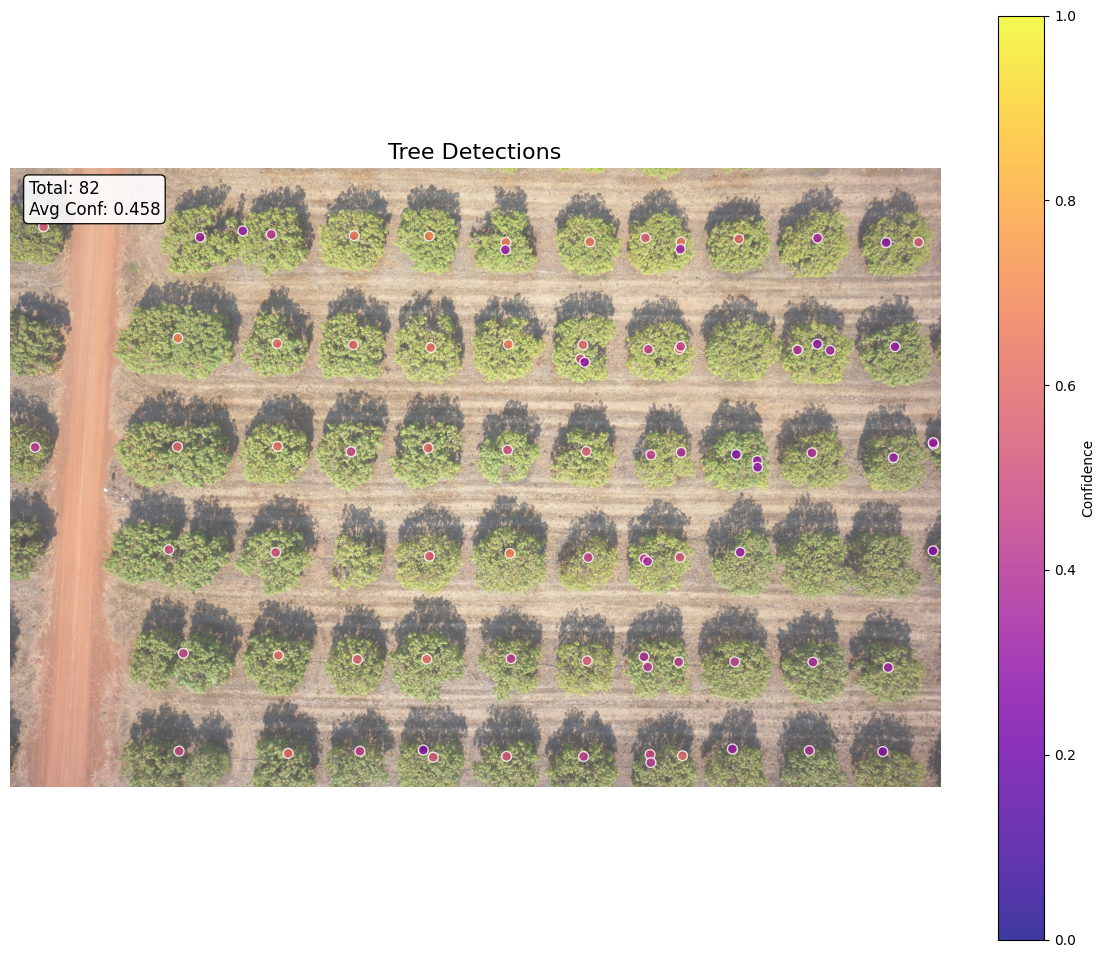

✓ Saved GeoJSON

DETECTION SUMMARY
Total detections: 82
Average confidence: 0.458
Confidence range: 0.261 - 0.690

SAVED FILES
✓ tree_detections.csv
✓ tree_points.geojson
✓ tree_boxes.csv
✓ tile_counts.csv
✓ tree_detections.png

CPU time used: 22.18 seconds


/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [22]:
# Main execution
tile_size = 1280
overlap = 8
resolution = 0.30
conf_threshold = 0.25
bands = [1, 2, 3]
image_path = '/content/drive/MyDrive/AGRI/Detection/tree_plantation.jpg'
output_dir = '/content/drive/MyDrive/AGRI/Detection'

print(f"Starting tree detection at {resolution}x resolution...")

# Run detection
all_points, detection_points_pixel, detection_boxes, counts_per_tile = detect_single_resolution(
    image_path=image_path,
    model=new_model,
    output_dir=output_dir,
    tile_size=tile_size,
    overlap=overlap,
    resolution=resolution,
    conf_threshold=conf_threshold
)

print("\nDetection complete! Creating visualization...")

# Create visualization
visualize_detections(image_path, detection_points_pixel, output_dir, bands)

# Save results
if detection_points_pixel:
    # Save detection points
    df_detections = pd.DataFrame(detection_points_pixel)
    df_detections.to_csv(f'{output_dir}/tree_detections.csv', index=False)

    # Save as GeoJSON
    if all_points:
        gdf_points = gpd.GeoDataFrame(geometry=all_points)
        gdf_points['confidence'] = [d['confidence'] for d in detection_points_pixel]
        gdf_points['tile_id'] = [d['tile_id'] for d in detection_points_pixel]

        try:
            gdf_points.to_file(f"{output_dir}/tree_points.geojson", driver="GeoJSON")
            print("✓ Saved GeoJSON")
        except Exception as e:
            print(f"⚠ Could not save GeoJSON: {e}")

    # Save bounding boxes
    df_boxes = pd.DataFrame(detection_boxes)
    df_boxes.to_csv(f'{output_dir}/tree_boxes.csv', index=False)

    # Save tile counts
    df_counts = pd.DataFrame(counts_per_tile)
    df_counts.to_csv(f'{output_dir}/tile_counts.csv', index=False)

# Print summary
print(f"\n{'='*50}")
print(f"DETECTION SUMMARY")
print(f"{'='*50}")
print(f"Total detections: {len(detection_points_pixel)}")
if detection_points_pixel:
    avg_conf = np.mean([d['confidence'] for d in detection_points_pixel])
    print(f"Average confidence: {avg_conf:.3f}")
    print(f"Confidence range: {min([d['confidence'] for d in detection_points_pixel]):.3f} - {max([d['confidence'] for d in detection_points_pixel]):.3f}")

print(f"\n{'='*50}")
print(f"SAVED FILES")
print(f"{'='*50}")
print(f"✓ tree_detections.csv")
print(f"✓ tree_points.geojson")
print(f"✓ tree_boxes.csv")
print(f"✓ tile_counts.csv")
print(f"✓ tree_detections.png")

end_cpu_time = time.process_time()
cpu_time_used = end_cpu_time - start_cpu_time
print(f"\n{'='*50}")
print(f"CPU time used: {cpu_time_used:.2f} seconds")
print(f"{'='*50}")